# RQ2: Are election years associated with significantly higher YouTube engagement on politically aligned channels compared to non-election years?

In [1]:
from pymongo import MongoClient
import pandas as pd

client = MongoClient("mongodb://localhost:27017/")
db = client["group4"]
collection = db["anes"]

pipeline = [
    # FILTER 
    {
        "$match": {
            "youtube_use": {"$ne": None},
            "lib_con_scale": {"$nin": ["DK", "Refused", None]},
            "democrat_thermometer": {"$ne": None},
            "republican_thermometer": {"$ne": None}
        }
    },

    # GROUP BY
    {
        "$group": {
            "_id": {
                "election_year": "$election_year",
                "youtube_use": "$youtube_use",
                "lib_con_scale": "$lib_con_scale"
            },
            "respondent_count": {"$sum": 1},
            "avg_dem": {"$avg": "$democrat_thermometer"},
            "avg_rep": {"$avg": "$republican_thermometer"}
        }
    },

    {
        "$project": {
            "_id": 0,
            "election_year": "$_id.election_year",
            "youtube_use": "$_id.youtube_use",
            "lib_con_scale": "$_id.lib_con_scale",
            "respondent_count": 1,
            "avg_dem_thermometer": {"$round": ["$avg_dem", 2]},
            "avg_rep_thermometer": {"$round": ["$avg_rep", 2]},
            "partisan_lean": {
                "$round": [
                    {"$subtract": ["$avg_dem", "$avg_rep"]},
                    2
                ]
            }
        }
    },

    # SORT
    {
        "$sort": {
            "election_year": 1,
            "youtube_use": 1,
            "lib_con_scale": 1
        }
    }
]

results = list(collection.aggregate(pipeline))
rq2_df = pd.DataFrame(results)

display(rq2_df.head())

,respondent_count,election_year,youtube_use,lib_con_scale,avg_dem_thermometer,avg_rep_thermometer,partisan_lean
0,13,2020,No,Conservative,26.77,73.38,-46.62
1,5,2020,No,Extremely Liberal,47.00,20.00,27.00
2,5,2020,No,Extremely conservative,18.00,91.00,-73.00
3,10,2020,No,Liberal,85.50,5.00,80.50
4,15,2020,No,Moderate,65.33,35.33,30.00


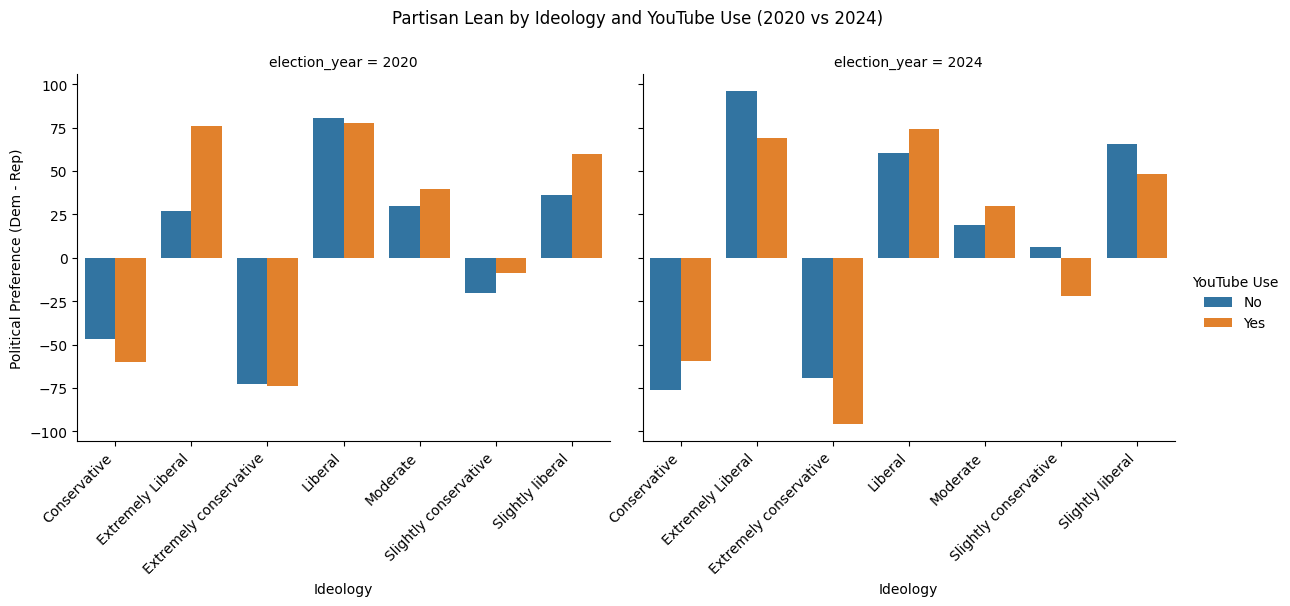

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=rq2_df,
    x="lib_con_scale",
    y="partisan_lean",
    hue="youtube_use",
    col="election_year",
    kind="bar",
    height=5,
    aspect=1.2
)
# Add legend
g._legend.set_title("YouTube Use")
for ax in g.axes.flat:
    ax.set_xlabel("Ideology")
    ax.set_ylabel("Political Preference (Dem - Rep)")
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
                      
plt.subplots_adjust(top=0.85)
plt.suptitle("Partisan Lean by Ideology and YouTube Use (2020 vs 2024)")

plt.show()